**Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

**Load Dataset**

In [2]:
from google.colab import files
uploaded = files.upload()

Saving breast-cancer.csv to breast-cancer (1).csv


In [24]:
df = pd.read_csv("/content/breast-cancer (1).csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [25]:
df = df.drop("id", axis=1)

In [26]:
print(df["diagnosis"].unique())

['M' 'B']


In [27]:
df["diagnosis"] = df["diagnosis"].astype(str).str.strip()

df["diagnosis"] = df["diagnosis"].apply(
    lambda x: 1 if x.upper() == "M" else 0
)

In [28]:
print(df["diagnosis"].unique())
print(df["diagnosis"].dtype)

[1 0]
int64


**Separate Features and Target**

In [29]:
X = df.drop("diagnosis", axis=1).values
y = df["diagnosis"].values

**Train/Test Split**

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Feature Scaling**


In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

***LOGISTIC REGRESSION FROM SCRATCH***

In [32]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [34]:
def initialize_parameters(n_features):
    w = np.zeros(n_features)
    b = 0
    return w, b

In [35]:
def compute_cost(X, y, w, b):
    m = len(y)
    z = np.dot(X, w) + b
    y_hat = sigmoid(z)

    epsilon = 1e-9
    cost = -(1/m) * np.sum(
        y*np.log(y_hat + epsilon) +
        (1-y)*np.log(1-y_hat + epsilon)
    )
    return cost

In [36]:
def gradient_descent(X, y, w, b, learning_rate, iterations):
    m = len(y)
    costs = []

    for i in range(iterations):
        z = np.dot(X, w) + b
        y_hat = sigmoid(z)

        dw = (1/m) * np.dot(X.T, (y_hat - y))
        db = (1/m) * np.sum(y_hat - y)

        w -= learning_rate * dw
        b -= learning_rate * db

        if i % 100 == 0:
            costs.append(compute_cost(X, y, w, b))

    return w, b, costs

**Train Model**

In [37]:
w, b = initialize_parameters(X_train.shape[1])

w, b, costs = gradient_descent(
    X_train, y_train,
    w, b,
    learning_rate=0.01,
    iterations=2000
)

In [15]:
print(df["diagnosis"].unique())
print(df["diagnosis"].dtype)

['M' 'B']
object


**Plot Cost Curve**

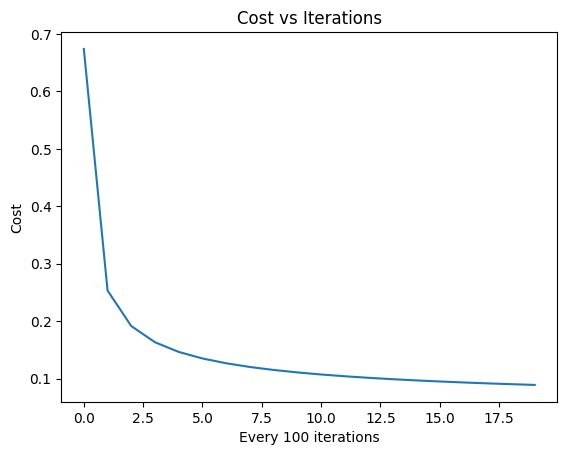

In [38]:
plt.plot(costs)
plt.title("Cost vs Iterations")
plt.xlabel("Every 100 iterations")
plt.ylabel("Cost")
plt.show()

In [39]:
def predict(X, w, b):
    z = np.dot(X, w) + b
    y_hat = sigmoid(z)
    return (y_hat >= 0.5).astype(int)

In [40]:
from sklearn.metrics import accuracy_score

y_pred_train = predict(X_train, w, b)
y_pred_test = predict(X_test, w, b)

print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))

Train Accuracy: 0.9824175824175824
Test Accuracy: 0.9912280701754386


**Train Sklearn Model**

In [41]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

y_pred_sklearn = model.predict(X_test)

print("Sklearn Test Accuracy:", accuracy_score(y_test, y_pred_sklearn))

Sklearn Test Accuracy: 0.9736842105263158


In [42]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_test))
print(classification_report(y_test, y_pred_test))

[[71  0]
 [ 1 42]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        71
           1       1.00      0.98      0.99        43

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



**Confusion Matrix**


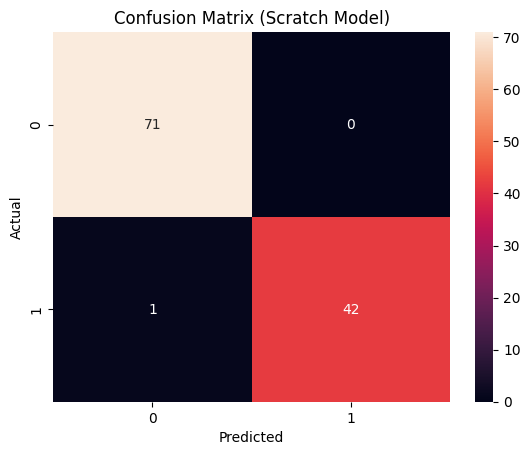

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_test)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (Scratch Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**ROC Curve**

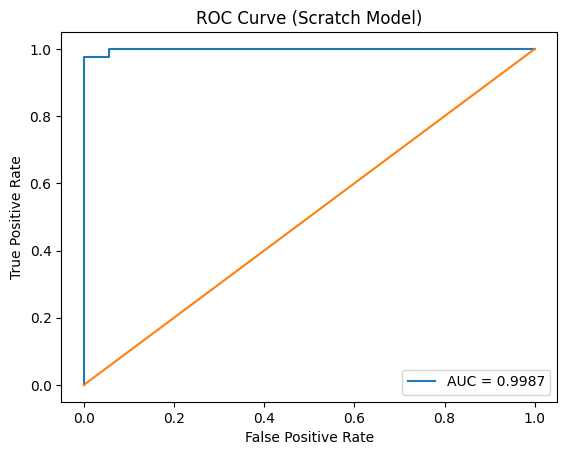

In [44]:
from sklearn.metrics import roc_curve, auc

# Get probabilities
z = np.dot(X_test, w) + b
y_prob = sigmoid(z)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Scratch Model)")
plt.legend()
plt.show()

**Feature Importance (Weight Magnitude)**

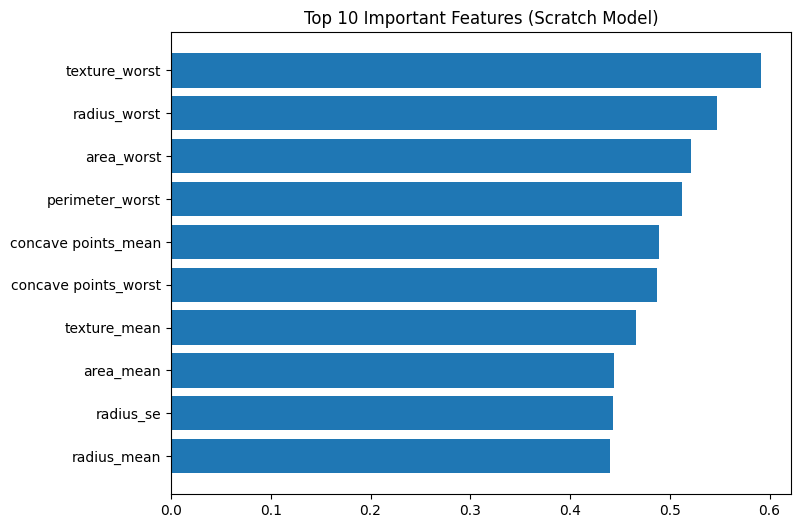

In [45]:
feature_names = df.drop("diagnosis", axis=1).columns

weights_df = pd.DataFrame({
    "Feature": feature_names,
    "Weight": w
})

weights_df["Absolute Weight"] = np.abs(weights_df["Weight"])
weights_df = weights_df.sort_values(by="Absolute Weight", ascending=False)

plt.figure(figsize=(8,6))
plt.barh(weights_df["Feature"][:10], weights_df["Absolute Weight"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features (Scratch Model)")
plt.show()

**Probability Distribution**


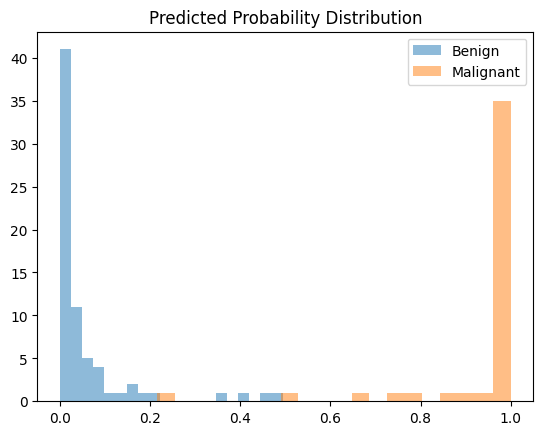

In [46]:
plt.figure()
plt.hist(y_prob[y_test==0], bins=20, alpha=0.5, label="Benign")
plt.hist(y_prob[y_test==1], bins=20, alpha=0.5, label="Malignant")
plt.legend()
plt.title("Predicted Probability Distribution")
plt.show()